Epoch 100 | Reg Loss: 0.0945 | Cls Loss: 0.0132
Epoch 200 | Reg Loss: 0.0686 | Cls Loss: 0.0087
Epoch 300 | Reg Loss: 0.0473 | Cls Loss: 0.0050
Epoch 400 | Reg Loss: 0.0316 | Cls Loss: 0.0027
Epoch 500 | Reg Loss: 0.0275 | Cls Loss: 0.0018
Epoch 600 | Reg Loss: 0.0212 | Cls Loss: 0.0011

--- 最终优化结果 ---
R-squared (R2): 0.2419
MAE: 43.3308


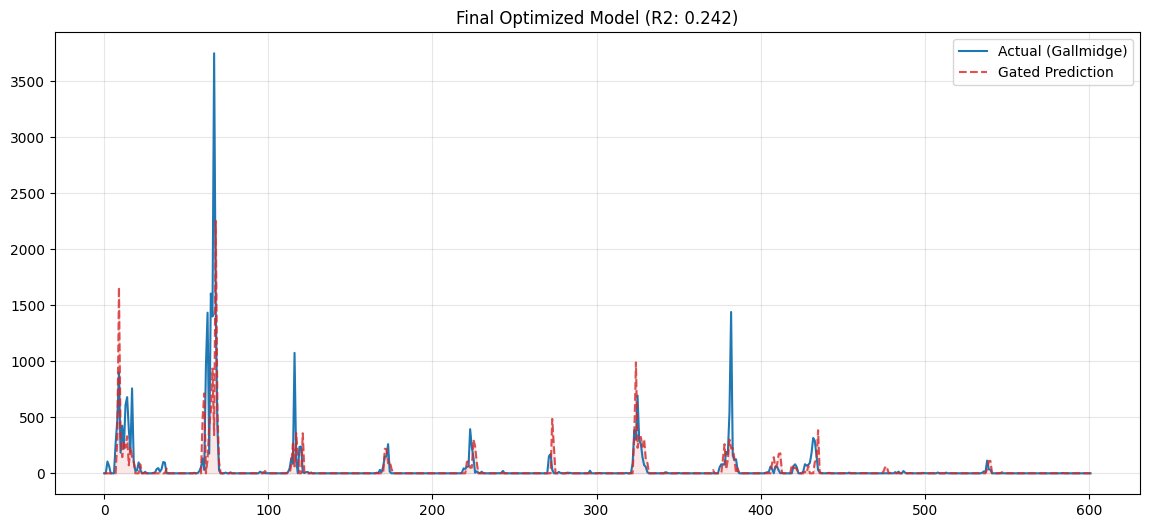

In [ ]:
import torch  
import torch.nn as nn  
import pandas as pd  
import numpy as np  
import matplotlib.pyplot as plt  
from sklearn.preprocessing import StandardScaler  
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error  
from scipy.interpolate import RBFInterpolator  
import plotly.graph_objects as go  
  
# --- 1. 设备检测 ---  
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  
  
# --- 2. 数据加载与深度特征工程 ---  
# [注意] 请确保你的 Google Drive 已挂载，且路径下有 RICE.csv 文件
try:
    df_raw = pd.read_csv('/content/drive/MyDrive/RICE.csv')
except FileNotFoundError:
    # 备用方案：如果是在本地运行，请修改此处的路径
    df_raw = pd.read_csv('RICE.csv')  

target_pest = "Gallmidge"  
df = df_raw[df_raw['PEST NAME'] == target_pest].copy()  
original_cols = ['Pest Value', 'MaxT', 'MinT', 'RH1(%)', 'RH2(%)', 'RF(mm)', 'WS(kmph)']  
df = df[original_cols].dropna().reset_index(drop=True)  
  
# 特征工程：增加滑动窗口特征，捕捉累积效应  
df['Rain_Sum_4wk'] = df['RF(mm)'].rolling(window=4).sum()  # 4周累积降雨  
df['Temp_Mean_4wk'] = df['MaxT'].rolling(window=4).mean() # 4周平均高温  
df = df.dropna().reset_index(drop=True)  
  
# 对数变换处理  
df['Pest Value'] = np.log1p(df['Pest Value'])  
  
# 定义爆发标签 (前20%定义为爆发态)  
threshold = df['Pest Value'].quantile(0.8)  
df['Is_Outbreak'] = (df['Pest Value'] > threshold).astype(float)  
  
# 更新特征列表  
feature_cols = ['Pest Value', 'MaxT', 'MinT', 'RH1(%)', 'RH2(%)', 'RF(mm)', 'WS(kmph)', 'Rain_Sum_4wk', 'Temp_Mean_4wk']  
scaler = StandardScaler()  
scaled_features = scaler.fit_transform(df[feature_cols])  
  
# --- 3. 构造序列数据 ---  
SEQ_LEN = 4  
  
def create_sequences(data, labels, seq_length):  
    xs, ys_reg, ys_cls = [], [], []  
    for i in range(len(data) - seq_length):  
        xs.append(data[i : i + seq_length, :])  
        ys_reg.append(data[i + seq_length, 0])  # 害虫数量
        ys_cls.append(labels[i + seq_length])    # 是否爆发
    return np.array(xs), np.array(ys_reg), np.array(ys_cls)  
  
X, y_reg, y_cls = create_sequences(scaled_features, df['Is_Outbreak'].values, SEQ_LEN)  
  
train_size = int(len(X) * 0.8)  
X_train = torch.FloatTensor(X[:train_size]).to(device)  
y_reg_train = torch.FloatTensor(y_reg[:train_size]).view(-1, 1).to(device)  
y_cls_train = torch.FloatTensor(y_cls[:train_size]).view(-1, 1).to(device)  
  
X_test = torch.FloatTensor(X[train_size:]).to(device)  
y_reg_test = y_reg[train_size:]  
y_cls_test = y_cls[train_size:]  
  
# --- 4. 定义 Focal Loss ---  
class FocalLoss(nn.Module):  
    def __init__(self, alpha=0.25, gamma=2):  
        super(FocalLoss, self).__init__()  
        self.alpha = alpha  
        self.gamma = gamma  
  
    def forward(self, inputs, targets):  
        bce_loss = nn.functional.binary_cross_entropy(inputs, targets, reduction='none')  
        pt = torch.exp(-bce_loss)  
        focal_loss = self.alpha * (1 - pt)**self.gamma * bce_loss  
        return focal_loss.mean()  
  
# --- 5. 改进的多任务模型架构 ---  
class EnhancedModel(nn.Module):  
    def __init__(self, n_features):  
        super(EnhancedModel, self).__init__()  
        self.cnn = nn.Sequential(  
            nn.Conv1d(n_features, 128, kernel_size=3, padding=1),  
            nn.BatchNorm1d(128),  
            nn.ReLU(),  
            nn.Dropout(0.2)  
        )  
        self.lstm = nn.LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.3)  
  
        # 分类头  
        self.classifier = nn.Sequential(  
            nn.Linear(256, 64),  
            nn.ReLU(),  
            nn.Linear(64, 1),  
            nn.Sigmoid()  
        )  
        # 回归头  
        self.regressor = nn.Sequential(  
            nn.Linear(256, 64),  
            nn.ReLU(),  
            nn.Linear(64, 1)  
        )  
  
    def forward(self, x):  
        x = x.transpose(1, 2)  
        x = self.cnn(x)  
        x = x.transpose(1, 2)  
        out, _ = self.lstm(x)  
        last_step = out[:, -1, :]  
        return self.regressor(last_step), self.classifier(last_step)  
  
# --- 6. 训练过程 ---  
model = EnhancedModel(n_features=len(feature_cols)).to(device)  
criterion_reg = nn.HuberLoss(delta=1.0) 
criterion_cls = FocalLoss()             
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)  
  
model.train()  
print("🚀 开始训练模型...")
for epoch in range(600):  
    optimizer.zero_grad()  
    pred_reg, pred_cls = model(X_train)  
  
    loss_reg = criterion_reg(pred_reg, y_reg_train)  
    loss_cls = criterion_cls(pred_cls, y_cls_train)  
  
    total_loss = loss_reg + 3.0 * loss_cls  
  
    total_loss.backward()  
    optimizer.step()  
  
    if (epoch + 1) % 100 == 0:  
        print(f"Epoch {epoch+1:03d} | Reg Loss: {loss_reg.item():.4f} | Cls Loss: {loss_cls.item():.4f}")  
  
# --- 7. 推理与门控验证 ---  
model.eval()  
with torch.no_grad():  
    raw_reg, raw_cls = model(X_test)  
    raw_reg = raw_reg.cpu().numpy()  
    raw_cls = raw_cls.cpu().numpy()  
  
gate_mask = (raw_cls < 0.5)  
final_reg = raw_reg.copy()  
final_reg[gate_mask] = -0.8  
  
mean_p, std_p = scaler.mean_[0], scaler.scale_[0]  
pred_y = np.expm1(final_reg * std_p + mean_p)  
real_y = np.expm1(y_reg_test * std_p + mean_p)  
pred_y = np.maximum(pred_y, 0)  
  
r2 = r2_score(real_y, pred_y)  
print(f"\n--- 验证集评估结果 ---")  
print(f"R-squared: {r2:.4f}\n")  



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 新段落